In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorboardX import SummaryWriter
import os
import time
from torcheval.metrics import R2Score
from sklearn.metrics import r2_score
import shap
import pickle
from sklearn.linear_model import LinearRegression
from scipy import stats
from decimal import Decimal
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")

%matplotlib inline
pd.set_option('display.max_columns', None)

In [15]:
deep_res_path = 'results/factor_v1/'
lr_res_path = 'results/linear_factor_v1/'

In [16]:
with open(os.path.join(deep_res_path, '0_0.pkl'), 'rb') as f:
    deep_factor_0_dict = pickle.load(f)

corr_max_idx = np.argmax(deep_factor_0_dict['alternative']['corr'])
corr_max = deep_factor_0_dict['alternative']['corr'][corr_max_idx]
r2_max = deep_factor_0_dict['alternative']['r2'][corr_max_idx]

corr_max, r2_max

(0.9999044458012261, 0.9997563594675709)

In [17]:
with open(os.path.join(lr_res_path, '0_0.pkl'), 'rb') as f:
    lr_factor_0_dict = pickle.load(f)

corr_max_idx = np.argmax(lr_factor_0_dict['alternative']['corr'])
corr_max = lr_factor_0_dict['alternative']['corr'][corr_max_idx]
r2_max = lr_factor_0_dict['alternative']['r2'][corr_max_idx]

corr_max, r2_max

(0.7766192175660651, 0.447723907606313)

In [18]:
names = ['0_0', '1_1', '2_2', '3_3', '4_4']

res_dict = dict(factor=list(), 
                model_type=list(), 
                corr_value_best=list(), 
                corr_value_mean=list(), 
                r2_value_best=list(), 
                r2_value_mean=list(), 
                loss_value_best=list(),
                loss_value_mean=list())
for i, name in enumerate(names):
    
    with open(os.path.join(deep_res_path, name + '.pkl'), 'rb') as f:
        deep_factor_dict = pickle.load(f)

#     best_idx = np.argmin(deep_factor_dict['alternative']['loss'])
#     best_idx = np.argmax(deep_factor_dict['alternative']['corr'])
    best_idx = np.argmax(deep_factor_dict['alternative']['r2'])
    corr_max = deep_factor_dict['alternative']['corr'][best_idx]
    corr_mean = np.mean(deep_factor_dict['alternative']['corr'])
    r2_max = deep_factor_dict['alternative']['r2'][best_idx]
    r2_mean = np.mean(deep_factor_dict['alternative']['r2'])
    loss_min = deep_factor_dict['alternative']['loss'][best_idx]
    loss_mean = np.mean(deep_factor_dict['alternative']['loss'])
    
    res_dict['factor'].append('factor_' + str(i))
    res_dict['model_type'].append('mlp')
    res_dict['corr_value_best'].append(corr_max)
    res_dict['corr_value_mean'].append(corr_mean)
    res_dict['r2_value_best'].append(r2_max)
    res_dict['r2_value_mean'].append(r2_mean)
    res_dict['loss_value_best'].append(loss_min)
    res_dict['loss_value_mean'].append(loss_mean)
    

    with open(os.path.join(lr_res_path, name + '.pkl'), 'rb') as f:
        lr_factor_dict = pickle.load(f)

#     best_idx = np.argmin(lr_factor_dict['alternative']['loss'])
#     best_idx = np.argmax(lr_factor_dict['alternative']['corr'])
    best_idx = np.argmax(lr_factor_dict['alternative']['r2'])
    corr_max = lr_factor_dict['alternative']['corr'][best_idx]
    corr_mean = np.mean(lr_factor_dict['alternative']['corr'])
    r2_max = lr_factor_dict['alternative']['r2'][best_idx]
    r2_mean = np.mean(lr_factor_dict['alternative']['r2'])
    loss_min = lr_factor_dict['alternative']['loss'][best_idx]
    loss_mean = np.mean(lr_factor_dict['alternative']['loss'])
    
    res_dict['factor'].append('factor_' + str(i))
    res_dict['model_type'].append('linear_regression')
    res_dict['corr_value_best'].append(corr_max)
    res_dict['corr_value_mean'].append(corr_mean)
    res_dict['r2_value_best'].append(r2_max)
    res_dict['r2_value_mean'].append(r2_mean)
    res_dict['loss_value_best'].append(loss_min)
    res_dict['loss_value_mean'].append(loss_mean)

    
df = pd.DataFrame(res_dict)

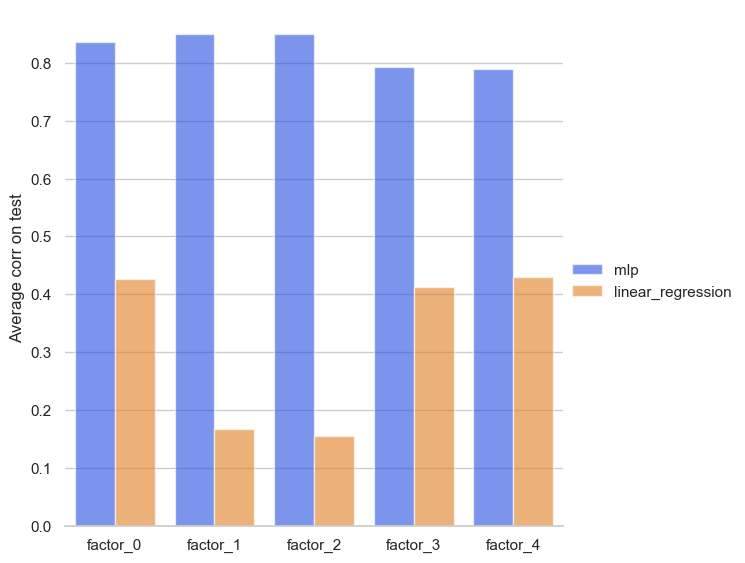

In [26]:
# Draw a nested barplot by species and sex
g = sns.catplot(data=df, kind="bar",
                x="factor", y="corr_value_mean", hue="model_type",
                errorbar="sd", palette="bright", alpha=.6, height=6)
g.despine(left=True)
g.set_axis_labels("", "Average corr on test")
g.legend.set_title("")
name = 'avg_corr_lr_mlp'
g.savefig("results/" + name + ".png") 